**HOUSE PRICE PREDICTION**

**Problem Statement:**

Predict house prices using property features such as area, bedrooms, bathrooms, and location. The goal is to build a regression model, evaluate its performance, and visualize predicted versus actual prices to understand factors affecting housing prices.

### Install Required Libraries

Install `scikit-learn` to access machine learning models and evaluation metrics for regression.
This command ensures all necessary libraries are available in the Colab environment.

In [ ]:
!pip install scikit-learn

### Import Libraries

- `pandas` and `numpy` for data manipulation and numerical operations  
- `matplotlib.pyplot` and `seaborn` for data visualization  
- `train_test_split` to split dataset into training and testing sets  
- `LinearRegression` to build the regression model  
- `mean_absolute_error` and `mean_squared_error` to evaluate model performance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Loading the Dataset

Load the house price dataset using pandas to begin analysis.

In [ ]:
df = pd.read_csv("House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Inspecting the Dataset

Check the number of rows and columns, data types, and summary statistics to understand the structure of the dataset.

In [ ]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (2000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


### Handling Missing Values

Check for missing values and removed them to ensure clean data for training the model.

In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df = df.dropna()

### Feature Selection

Select area, bedrooms, floors, yearbuilt,  garage, location, condition and bathrooms as input features.
The target variable is price, which we want to predict.

In [ ]:
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Garage']]
y = df['Price']

In [ ]:
X = pd.get_dummies(df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Garage', 'Location', 'Condition']], drop_first=True)
y = df['Price']

### Splitting the Dataset

Split the data into training (80%) and testing (20%) sets to evaluate model performance properly.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Training the Model

Use Linear Regression to train the model on the training data.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Making Predictions

After training, predict house prices using the test dataset.

In [ ]:
y_pred = model.predict(X_test)

### Model Evaluation

Evaluate the model using MAE and RMSE to measure prediction accuracy.
Lower values indicate better performance.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 243241.97758826384
Root Mean Squared Error: 279859.72583784326


### Visualization of Results

This scatter plot compares actual prices with predicted prices.
If predictions are accurate, points should lie close to a straight line.

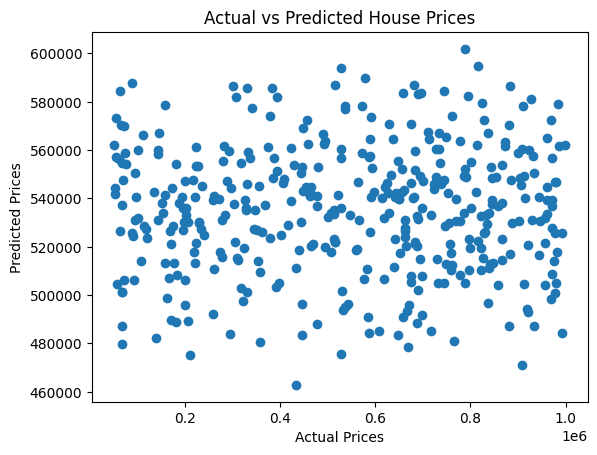

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Conclusion

I built a Linear Regression model to predict house prices.
The model is evaluated using MAE and RMSE.
The results show how property features like area and bedrooms affect house prices.